# MERIDA HRES — 1h Annual Maxima & Return Period Maps

**Pipeline overview**
1. Data inventory & integrity check
2. Single-file inspection (structure, units, CRS, time axis)
3. Extract 1h annual maxima (BM) across all files → `(years, y, x)` array
4. GEV fit pixel-wise with L-moments + MLE fallback
5. Compute RP quantile maps for [2, 5, 10, 25, 50, 100, 200] yr
6. Export GeoTIFFs (EPSG:4326 or native CRS)
7. Quick-look plots

**Assumptions / adjust to your setup**
- Files are `MERIDA_HRES_PREC_YYYYMM.nc`, one month each
- Variable name is `precipitation` (check §2 and change `PREC_VAR` if needed)
- Units are kg m⁻² h⁻¹ (= mm/h); if accumulated mm, set `IS_ACCUMULATED = True`
- All files on same grid; no reprojection needed inside the loop

## 0 · Imports & configuration

In [ ]:
import os
import re
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import rasterio
from rasterio.transform import from_bounds
from scipy.stats import genextreme as gev_scipy
from scipy.optimize import minimize

warnings.filterwarnings('ignore')

# ── USER SETTINGS ──────────────────────────────────────────────────────────────
DATA_DIR       = Path("/home/admin_climatecharted_com/data/MERIDA_HRES")
OUT_DIR        = Path("/home/admin_climatecharted_com/data/MERIDA_HRES/outputs/MERIDA_HRES_RP")
os.makedirs(OUT_DIR, exist_ok=True)
PREC_VAR       = "tp"              # confirmed from inspection
IS_ACCUMULATED = True              # WRF 'Precipitazione Totale' (kg/m²) = accumulated
                                   # → will diff per continuous WRF run segment
DURATION_H     = 1                 # 1-hour duration (native timestep = 1h, no rolling needed)
RETURN_PERIODS = [2, 5, 10, 25, 50, 100, 200]
N_JOBS         = 4                 # (reserved for future parallelism)
# ───────────────────────────────────────────────────────────────────────────────

OUT_DIR.mkdir(parents=True, exist_ok=True)
print(f"Output directory: {OUT_DIR.resolve()}")

Output directory: /home/admin_climatecharted_com/GitHub/hazard-heavy-rain/outputs/MERIDA_HRES_RP


## 1 · Data inventory

In [2]:
files = sorted(DATA_DIR.glob("MERIDA_HRES_PREC_*.nc"))
print(f"Total files found: {len(files)}")

# Parse YYYYMM from filename
pat = re.compile(r"MERIDA_HRES_PREC_(\d{4})(\d{2})\.nc")
records = []
for f in files:
    m = pat.search(f.name)
    if m:
        records.append({"path": f, "year": int(m.group(1)), "month": int(m.group(2)),
                        "size_mb": f.stat().st_size / 1e6})

df_inv = pd.DataFrame(records).sort_values(["year","month"]).reset_index(drop=True)

print(f"\nYear range : {df_inv.year.min()} – {df_inv.year.max()}")
print(f"Months/year expected: 12")

# Check for missing months
years = range(df_inv.year.min(), df_inv.year.max()+1)
missing = []
for y in years:
    for mo in range(1,13):
        if not ((df_inv.year==y) & (df_inv.month==mo)).any():
            missing.append(f"{y}-{mo:02d}")

if missing:
    print(f"\n⚠ Missing months ({len(missing)}): {missing}")
else:
    print("\n✓ No missing months")

# File size distribution
print(f"\nFile size  min={df_inv.size_mb.min():.1f} MB  "
      f"max={df_inv.size_mb.max():.1f} MB  "
      f"mean={df_inv.size_mb.mean():.1f} MB")

# Flag suspiciously small files (possible corrupt/empty)
thresh = df_inv.size_mb.median() * 0.1
small  = df_inv[df_inv.size_mb < thresh]
if len(small):
    print(f"\n⚠ Suspiciously small files (< {thresh:.1f} MB):")
    print(small[["path","year","month","size_mb"]])
else:
    print("✓ No suspiciously small files")

df_inv.tail()

Total files found: 468

Year range : 1986 – 2024
Months/year expected: 12

✓ No missing months

File size  min=285.7 MB  max=316.3 MB  mean=310.6 MB
✓ No suspiciously small files


,path,year,month,size_mb
463,/home/admin_climatecharted_com/data/MERIDA_HRE...,2024,8,316.315812
464,/home/admin_climatecharted_com/data/MERIDA_HRE...,2024,9,306.114180
465,/home/admin_climatecharted_com/data/MERIDA_HRE...,2024,10,316.315812
466,/home/admin_climatecharted_com/data/MERIDA_HRE...,2024,11,306.114180
467,/home/admin_climatecharted_com/data/MERIDA_HRE...,2024,12,316.315812


## 2 · Single-file deep inspection

In [5]:
# Use the first file for inspection; repeat on a 'problem' file if needed
sample_path = df_inv.iloc[-1].path
print(f"Inspecting: {sample_path.name}\n")

ds = xr.open_dataset(sample_path, engine="netcdf4")
print(ds)
print("\n--- Variables ---")
for v in ds.data_vars:
    d = ds[v]
    print(f"  {v:30s}  dims={d.dims}  shape={d.shape}  dtype={d.dtype}")
    if "units" in d.attrs: print(f"    units = {d.attrs['units']}")
    if "long_name" in d.attrs: print(f"    long_name = {d.attrs['long_name']}")

print("\n--- Coordinates ---")
for c in ds.coords:
    print(f"  {c:20s}  {ds[c].values[:3]} … {ds[c].values[-3:]}")

print("\n--- Global attributes ---")
for k,v in ds.attrs.items():
    print(f"  {k}: {v}")

Inspecting: MERIDA_HRES_PREC_202412.nc

<xarray.Dataset> Size: 316MB
Dimensions:  (XTIME: 744, lat: 323, lon: 329)
Coordinates:
  * XTIME    (XTIME) datetime64[ns] 6kB 2024-12-01 ... 2024-12-31T23:00:00
  * lat      (lat) float32 1kB 48.25 48.21 48.17 48.13 ... 35.45 35.41 35.37
  * lon      (lon) float32 1kB 5.84 5.88 5.92 5.96 ... 18.84 18.88 18.92 18.96
Data variables:
    tp       (XTIME, lat, lon) float32 316MB ...
Attributes: (12/14)
    CDI:            Climate Data Interface version 1.9.10 (https://mpimet.mpg...
    source:         WRF3.9
    institution:    RSE S.p.A. - Ricerca sul Sistema Energetico
    Conventions:    CF-1.6
    title:          MERIDA HRES - MEteorological Reanalysis Italian DAtaset H...
    version:        v1
    ...             ...
    frequency:      1 hr
    references:     Lacavalla,M., Bonanno,R., Sperati,S.,2020. Dataset MERIDA...
    NCO:            netCDF Operators version 4.8.1 (Homepage = http://nco.sf....
    funding:        This work has been fin

In [6]:
# Auto-detect precipitation variable if default doesn't exist
if PREC_VAR not in ds.data_vars:
    candidates = [v for v in ds.data_vars
                  if any(k in v.lower() for k in ["prec","precip","rain","tp","pr"])]
    if candidates:
        PREC_VAR = candidates[0]
        print(f"Auto-detected PREC_VAR = '{PREC_VAR}'")
    else:
        print(f"⚠ Could not detect precip variable. Available: {list(ds.data_vars)}")
        print("  → Set PREC_VAR manually in §0")
else:
    print(f"✓ PREC_VAR = '{PREC_VAR}' found")

# Time-axis inspection
t = ds.XTIME.values
print(f"\nTime axis: {len(t)} steps")
print(f"  First : {pd.Timestamp(t[0])}")
print(f"  Last  : {pd.Timestamp(t[-1])}")
dt_hours = (pd.Timestamp(t[1]) - pd.Timestamp(t[0])).total_seconds() / 3600
print(f"  Δt    : {dt_hours:.2f} h")

if dt_hours != 1.0:
    print(f"\n⚠ Timestep is {dt_hours}h, not 1h — check DURATION_H or resample strategy")

# Spatial bounds
lat = ds["lat"].values if "lat" in ds.coords else ds["latitude"].values
lon = ds["lon"].values if "lon" in ds.coords else ds["longitude"].values
print(f"\nSpatial: lat [{lat.min():.3f} … {lat.max():.3f}]  "
      f"lon [{lon.min():.3f} … {lon.max():.3f}]")
print(f"Grid size: {len(lat)} × {len(lon)}")

ds.close()

✓ PREC_VAR = 'tp' found

Time axis: 744 steps
  First : 2024-12-01 00:00:00
  Last  : 2024-12-31 23:00:00
  Δt    : 1.00 h

Spatial: lat [35.370 … 48.250]  lon [5.840 … 18.960]
Grid size: 323 × 329


TypeError: No numeric data to plot.

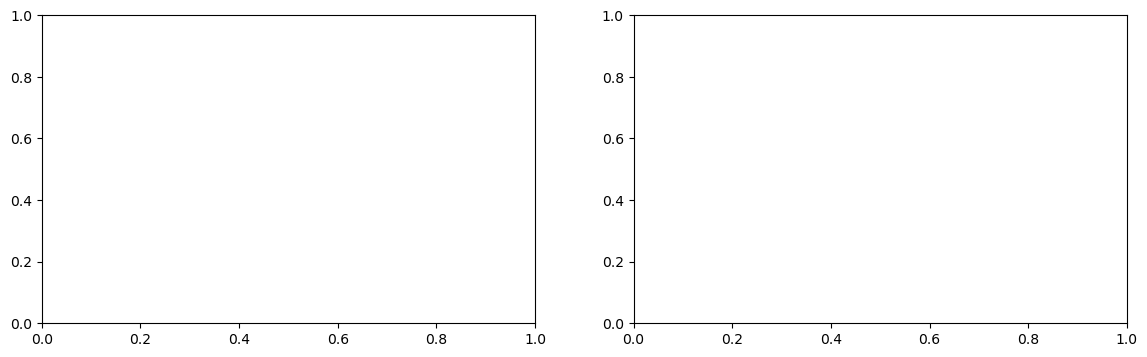

In [7]:
# Quick spatial and temporal plot of the sample file
ds = xr.open_dataset(sample_path)
da = ds[PREC_VAR]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Spatial mean
da.mean(dim=[d for d in da.dims if d != 'time']).plot(ax=axes[0])
axes[0].set_title("Hourly domain-mean precip (mm/h)")

# Spatial snapshot — time-mean
da.mean(dim="time").plot(ax=axes[1], cmap="Blues")
axes[1].set_title("Time-mean precip")

plt.tight_layout()
plt.savefig(OUT_DIR / "00_sample_inspection.png", dpi=120)
plt.show()
ds.close()

## 3 · Extract 1h annual maxima (Block Maxima)

In [8]:
# ── Helpers ──────────────────────────────────────────────────────────────────
def get_latlon_names(ds):
    lat_names = ["lat", "latitude", "y"]
    lon_names = ["lon", "longitude", "x"]
    latname = next((n for n in lat_names if n in ds.coords), None)
    lonname = next((n for n in lon_names if n in ds.coords), None)
    return latname, lonname


def normalise_time(ds):
    """
    MERIDA HRES has two time-dimension naming conventions:
      - Older files (≤ ~2019):  dim='Times', values are float YYYYMMDD.frac
      - Newer files (≥ ~2020):  dim='XTIME', values are proper datetime64
    Returns a DataArray of the precip variable with a normalised 'time' dim
    carrying pandas DatetimeIndex values.
    """
    time_dim = next((d for d in ds.dims if d in ("Times", "XTIME", "time")), None)
    if time_dim is None:
        raise ValueError(f"Cannot find time dimension. Dims: {list(ds.dims)}")

    da = ds[PREC_VAR]

    if time_dim in ("XTIME", "time"):
        # Already datetime64 — just rename if needed
        if time_dim != "time":
            da = da.rename({time_dim: "time"})
        return da

    # ── 'Times' branch: float YYYYMMDD.fraction → datetime64 ─────────────────
    float_vals = ds[time_dim].values.astype(float)
    timestamps = []
    for fv in float_vals:
        date_part = int(fv)
        frac      = fv - date_part
        year_  = date_part // 10000
        month_ = (date_part % 10000) // 100
        day_   = date_part % 100
        total_seconds = round(frac * 86400)
        hour_  = total_seconds // 3600
        minute_= (total_seconds % 3600) // 60
        timestamps.append(pd.Timestamp(year_, month_, day_, hour_, minute_))
    dt_index = pd.DatetimeIndex(timestamps)
    da = da.assign_coords({time_dim: dt_index}).rename({time_dim: "time"})
    return da


def month_hourly_increments(da):
    """
    Convert WRF accumulated totals to hourly increments.
    WRF resets accumulation at each run initialisation; with 1-month files and
    typical 1-month runs the whole file is one continuous accumulation sequence,
    so a simple diff along time is correct.  Negative diffs (reset artefacts at
    init boundary) are clipped to zero.
    """
    return da.diff(dim="time").clip(min=0)


# ── Grid reference from first file ───────────────────────────────────────────
ds0 = xr.open_dataset(df_inv.iloc[0].path)
latname, lonname = get_latlon_names(ds0)
lat_ref = ds0[latname].values
lon_ref = ds0[lonname].values
ny, nx  = len(lat_ref), len(lon_ref)
print(f"Grid: {ny} × {nx}  (lat × lon)")
ds0.close()

# ── Loop over years ───────────────────────────────────────────────────────────
unique_years = sorted(df_inv.year.unique())
n_years      = len(unique_years)
print(f"Processing {n_years} years: {unique_years[0]} – {unique_years[-1]}")

ann_max = np.full((n_years, ny, nx), np.nan, dtype=np.float32)

for yi, year in enumerate(unique_years):
    month_rows  = df_inv[df_inv.year == year].sort_values("month")
    month_files = month_rows.path.tolist()
    if len(month_files) < 12:
        print(f"  ⚠ {year}: only {len(month_files)} months — may bias low")

    # Process month by month to avoid mixing accumulation resets across files
    monthly_maxima = []
    for fpath in month_files:
        ds_m  = xr.open_dataset(fpath, engine="netcdf4")
        da_m  = normalise_time(ds_m)   # → 'time' dim, datetime64

        if IS_ACCUMULATED:
            da_m = month_hourly_increments(da_m)  # diff within this file only

        if DURATION_H > 1:
            da_m = da_m.rolling(time=DURATION_H, min_periods=DURATION_H).sum()

        monthly_maxima.append(da_m.max(dim="time").values)
        ds_m.close()

    # Annual maximum = element-wise max across monthly maxima
    stacked = np.stack(monthly_maxima, axis=0)          # (n_months, ny, nx)
    ann_max[yi] = np.nanmax(stacked, axis=0)

    if (yi+1) % 5 == 0 or yi == n_years - 1:
        print(f"  {year} done ({yi+1}/{n_years})")

print("\n✓ Annual maxima extraction complete")
print(f"  ann_max shape: {ann_max.shape}   NaN count: {np.isnan(ann_max).sum()}")

Grid: 323 × 329  (lat × lon)
Processing 39 years: 1986 – 2024
  1990 done (5/39)
  1995 done (10/39)
  2000 done (15/39)
  2005 done (20/39)
  2010 done (25/39)
  2015 done (30/39)
  2020 done (35/39)
  2024 done (39/39)

✓ Annual maxima extraction complete
  ann_max shape: (39, 323, 329)   NaN count: 43953


In [10]:
OUT_DIR        = Path("/home/admin_climatecharted_com/data/MERIDA_HRES/outputs/MERIDA_HRES_RP")
os.makedirs(OUT_DIR, exist_ok=True)

# Save ann_max as NetCDF for reuse (avoids rerunning the loop)
ds_am = xr.Dataset(
    {"ann_max_1h": (["year", latname, lonname], ann_max,
                    {"units": "mm", "long_name": "1-hour annual maximum precipitation"})},
    coords={"year": unique_years, latname: lat_ref, lonname: lon_ref}
)
am_path = OUT_DIR / "MERIDA_HRES_annmax_1h.nc"
ds_am.to_netcdf(am_path)
print(f"Saved: {am_path}")

Saved: /home/admin_climatecharted_com/data/MERIDA_HRES/outputs/MERIDA_HRES_RP/MERIDA_HRES_annmax_1h.nc


### 3.1 · Annual maxima diagnostics

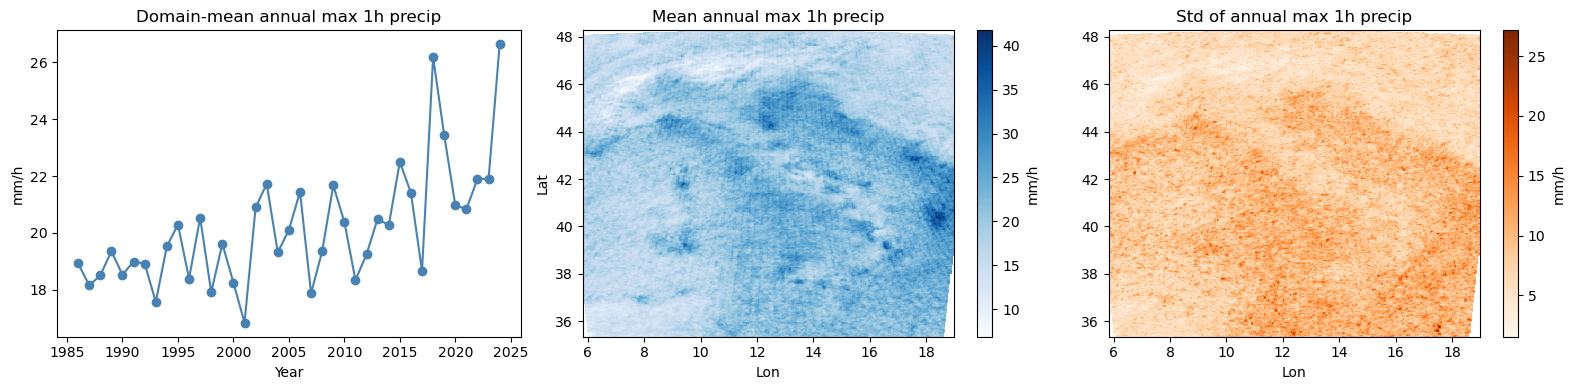

In [ ]:
# Domain-mean annual maxima trend
am_mean = np.nanmean(ann_max, axis=(1,2))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(unique_years, am_mean, 'o-', color='steelblue')
axes[0].set_title("Domain-mean annual max 1h precip")
axes[0].set_ylabel("mm/h")
axes[0].set_xlabel("Year")

# Spatial map of long-term mean of annual maxima
mean_map = np.nanmean(ann_max, axis=0)
im = axes[1].pcolormesh(lon_ref, lat_ref, mean_map, cmap="Blues", shading="auto")
plt.colorbar(im, ax=axes[1], label="mm/h")
axes[1].set_title("Mean annual max 1h precip")
axes[1].set_xlabel("Lon"); axes[1].set_ylabel("Lat")

# Spatial map of inter-annual std
std_map = np.nanstd(ann_max, axis=0)
im2 = axes[2].pcolormesh(lon_ref, lat_ref, std_map, cmap="Oranges", shading="auto")
plt.colorbar(im2, ax=axes[2], label="mm/h")
axes[2].set_title("Std of annual max 1h precip")
axes[2].set_xlabel("Lon")

plt.tight_layout()
plt.savefig(OUT_DIR / "01_annmax_diagnostics.png", dpi=120)
plt.show()

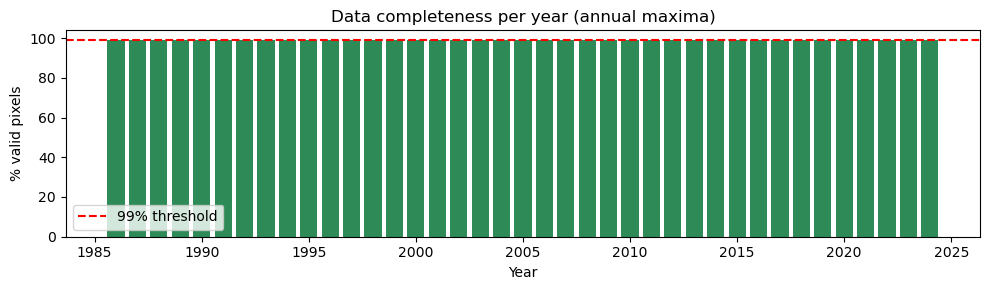

In [ ]:
# NaN / valid pixel census per year
valid_pct = np.mean(~np.isnan(ann_max), axis=(1,2)) * 100
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(unique_years, valid_pct, color="seagreen")
ax.axhline(99, color="red", linestyle="--", label="99% threshold")
ax.set_ylabel("% valid pixels")
ax.set_xlabel("Year")
ax.set_title("Data completeness per year (annual maxima)")
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / "02_data_completeness.png", dpi=120)
plt.show()

if (valid_pct < 95).any():
    bad_years = [y for y, v in zip(unique_years, valid_pct) if v < 95]
    print(f"⚠ Years with < 95% valid pixels: {bad_years}")

## 4 · GEV fitting (pixel-wise)

**Changes from v1**

| Issue | Fix |
|---|---|
| Shape clipped to `(−0.5, 0.5)` allowed Weibull-bounded fits (scipy `c > 0`), producing flat RP curves (e.g. Milan RP200 ≈ RP10 + 4 mm/h) | Clip tightened to `(−0.4, 0.1)` |
| MLE fallback never triggered — `sc ≤ 0` check was insufficient | Fallback now also fires when L-mom returns `shape > 0.05` (Weibull-suspect on short records) |
| L-mom location/scale were recomputed with the *unclipped* k, then shape clipped afterward — inconsistent | Scale/location now recomputed from the *clipped* shape |
| No indication of which pixels are Weibull-bounded vs Fréchet | Shape histogram now marks constraint bounds; new RP100/RP10 growth-ratio map |


In [ ]:
import math

# ── Shape constraint (scipy convention) ─────────────────────────────────────
# In scipy: shape < 0  → Fréchet type  (unbounded heavy upper tail)  ← desired
#           shape ≈ 0  → Gumbel        (exponential upper tail)
#           shape > 0  → Weibull type  (bounded above at loc + scale/shape)
# With 39-year records, L-moments frequently returns positive shapes;
# setting SHAPE_HI = 0.1 limits this artefact while preserving slight Weibull fits.
SHAPE_LO  = -0.4   # Fréchet limit  (very heavy tail)
SHAPE_HI  =  0.1   # Weibull limit  (mild bounded-above, larger values unreliable at n=39)
MIN_YEARS = 15     # minimum sample size for fitting


def gev_lmom(data):
    """L-moments GEV fit (Hosking 1985).  Returns (loc, scale, shape_scipy).

    scipy shape = −k  (Hosking k > 0 → Fréchet → scipy shape < 0).
    Scale and location are recomputed from the *clipped* shape to maintain
    internal consistency.
    """
    x = np.sort(data[~np.isnan(data)])
    n = len(x)
    if n < MIN_YEARS:
        return np.nan, np.nan, np.nan
    i   = np.arange(1, n + 1, dtype=float)
    b0  = np.mean(x)
    b1  = np.sum((i - 1) / (n * (n - 1)) * x)
    b2  = np.sum((i - 1) * (i - 2) / (n * (n - 1) * (n - 2)) * x)
    l2  = 2.0 * b1 - b0
    l3  = 6.0 * b2 - 6.0 * b1 + b0
    if l2 <= 0:
        return np.nan, np.nan, np.nan
    t3 = l3 / l2
    # Hosking (1985) rational approximation for k
    c  = 2.0 / (3.0 + t3) - np.log(2.0) / np.log(3.0)
    k  = 7.8590 * c + 2.9554 * c ** 2   # Hosking k
    # Convert to scipy and apply constraint
    shape_scipy = float(np.clip(-k, SHAPE_LO, SHAPE_HI))
    k_eff = -shape_scipy   # Hosking k matching the clipped scipy shape
    try:
        g1 = math.gamma(1.0 + k_eff)
    except (ValueError, OverflowError):
        return np.nan, np.nan, np.nan
    if abs(k_eff) > 1e-6:
        denom = (1.0 - 2.0 ** (-k_eff)) * g1
        if abs(denom) < 1e-12:
            return np.nan, np.nan, np.nan
        alpha = l2 * k_eff / denom
    else:
        alpha = l2 / np.log(2.0)   # Gumbel limit
    if np.isnan(alpha) or alpha <= 0:
        return np.nan, np.nan, np.nan
    xi = b0 - alpha / k_eff * (1.0 - g1) if abs(k_eff) > 1e-6 else b0 - alpha * 0.5772
    return float(xi), float(alpha), shape_scipy


def gev_mle(data):
    """MLE GEV fit with constrained shape."""
    x = data[~np.isnan(data)]
    if len(x) < MIN_YEARS:
        return np.nan, np.nan, np.nan
    try:
        shape, loc, scale = gev_scipy.fit(x, method='MLE')
        shape = float(np.clip(shape, SHAPE_LO, SHAPE_HI))
        if scale <= 0:
            return np.nan, np.nan, np.nan
        return float(loc), float(scale), shape
    except Exception:
        return np.nan, np.nan, np.nan


def _lmom_needs_fallback(loc, sc, sh):
    """Return True if L-moments result is implausible → try MLE."""
    if np.isnan(loc) or sc <= 0:
        return True
    # scipy shape > 0.05 on a ~40-year record almost always reflects
    # sampling noise rather than a physically bounded distribution.
    if sh > 0.05:
        return True
    return False


print(f'Shape constraint : [{SHAPE_LO}, {SHAPE_HI}]  '
      f'(scipy; negative = Fréchet, positive = Weibull)')
print(f'Min sample size  : {MIN_YEARS} years')
print('GEV fitting functions defined.')

In [ ]:
gev_loc   = np.full((ny, nx), np.nan, dtype=np.float32)
gev_scale = np.full((ny, nx), np.nan, dtype=np.float32)
gev_shape = np.full((ny, nx), np.nan, dtype=np.float32)
fit_flag  = np.zeros((ny, nx), dtype=np.int8)
# fit_flag: 0=insufficient data, 1=L-moments, 2=MLE fallback, 3=failed

print(f'Fitting GEV for {ny * nx:,} pixels ({n_years} years each)…')

for j in range(ny):
    for i in range(nx):
        series = ann_max[:, j, i]
        valid  = series[~np.isnan(series)]
        if len(valid) < MIN_YEARS:
            fit_flag[j, i] = 0
            continue
        loc, sc, sh = gev_lmom(series)
        if _lmom_needs_fallback(loc, sc, sh):
            loc, sc, sh = gev_mle(series)
            fit_flag[j, i] = 2 if not np.isnan(loc) else 3
        else:
            fit_flag[j, i] = 1
        gev_loc[j, i]   = loc
        gev_scale[j, i] = sc
        gev_shape[j, i] = sh

n_lmom   = int(np.sum(fit_flag == 1))
n_mle    = int(np.sum(fit_flag == 2))
n_fail   = int(np.sum(fit_flag == 3))
n_insuff = int(np.sum(fit_flag == 0))
n_ok     = n_lmom + n_mle
print(f'\n✓ Fit summary: {n_ok:,} pixels fitted')
print(f'  L-moments      : {n_lmom:,}')
print(f'  MLE fallback   : {n_mle:,}  (triggered by implausible L-mom shape)')
print(f'  Failed         : {n_fail:,}')
print(f'  Insufficient   : {n_insuff:,}  (< {MIN_YEARS} valid years)')
print(f'\nShape range (fitted pixels): '
      f'[{np.nanmin(gev_shape):.3f}, {np.nanmax(gev_shape):.3f}]')
print(f'  Median ξ       : {np.nanmedian(gev_shape):.3f}  '
      f'(negative = Fréchet/heavy-tail, positive = Weibull/bounded)')

In [ ]:
# ── GEV parameter maps ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
titles = ['Location μ (mm/h)', 'Scale σ (mm/h)', 'Shape ξ']
cmaps  = ['Blues', 'Purples', 'RdBu_r']
params = [gev_loc, gev_scale, gev_shape]
sh_abs = float(np.nanpercentile(np.abs(gev_shape[~np.isnan(gev_shape)]), 98))

for k, (ax, p, t, c) in enumerate(zip(axes, params, titles, cmaps)):
    kw = dict(cmap=c, shading='auto')
    if k == 2:
        kw.update(vmin=-sh_abs, vmax=sh_abs)   # symmetric around 0
    im = ax.pcolormesh(lon_ref, lat_ref, p, **kw)
    plt.colorbar(im, ax=ax, label=t)
    ax.set_title(t); ax.set_xlabel('Lon'); ax.set_ylabel('Lat')

plt.tight_layout()
plt.savefig(OUT_DIR / '03_gev_parameters.png', dpi=120)
plt.show()

# ── Shape histogram with constraint markers ────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
sh_vals = gev_shape[~np.isnan(gev_shape)].ravel()
ax.hist(sh_vals, bins=80, color='steelblue', edgecolor='none', density=True)
ax.axvline(0,        color='k',      linestyle='--', lw=1.2, label='ξ=0 (Gumbel)')
ax.axvline(SHAPE_LO, color='orange', linestyle=':',  lw=1.2, label=f'Constraint lower ({SHAPE_LO})')
ax.axvline(SHAPE_HI, color='red',    linestyle=':',  lw=1.2, label=f'Constraint upper ({SHAPE_HI})')
ax.set_xlabel('Shape ξ (scipy)'); ax.set_ylabel('Density')
ax.set_title('GEV shape parameter distribution')
ax.legend(fontsize=8)
pct_at_hi = 100 * float(np.mean(sh_vals >= SHAPE_HI - 0.005))
pct_at_lo = 100 * float(np.mean(sh_vals <= SHAPE_LO + 0.005))
ax.text(0.97, 0.95, f'{pct_at_hi:.1f}% at upper bound  |  {pct_at_lo:.1f}% at lower bound',
        transform=ax.transAxes, ha='right', va='top', fontsize=8, color='red')
plt.tight_layout()
plt.savefig(OUT_DIR / '04_gev_shape_histogram.png', dpi=120)
plt.show()

## 5 · Return period quantile maps

**Quantile formula** (Coles 2001, §3.1):

$$Q(T) = \mu + \frac{\sigma}{\xi}\left[(-\ln(1-1/T))^{-\xi} - 1\right]$$

with the Gumbel limit $Q(T) = \mu - \sigma\ln(-\ln(1-1/T))$ when $|\xi| < 10^{-6}$.

**Note:** This is mathematically identical to `scipy.stats.genextreme.ppf(1-1/T, c=ξ, loc=μ, scale=σ)`.

In [ ]:
def gev_quantile(loc, scale, shape, T):
    """Vectorised GEV quantile.  Equivalent to gev_scipy.ppf(1-1/T, c=shape, loc=loc, scale=scale).

    Derivation:
        GEV CDF:  F(x) = exp(-(1 + shape*(x-loc)/scale)^(-1/shape))   shape != 0
        Invert:   x    = loc + scale/shape * (y^{-shape} - 1)
        where y = -ln(F) = -ln(1-1/T)    (exceedance frequency)
    """
    p = 1.0 - 1.0 / T
    y = -np.log(p)   # = -log(1 - 1/T); always > 0 for T > 1
    with np.errstate(divide='ignore', invalid='ignore', over='ignore'):
        q = np.where(
            np.abs(shape) < 1e-6,
            loc - scale * np.log(y),                     # Gumbel limit
            loc + scale / shape * (y ** (-shape) - 1.0)  # full GEV
        )
    return np.where(np.isnan(loc), np.nan, q).astype(np.float32)


rp_maps = {}
for T in RETURN_PERIODS:
    rp_maps[T] = gev_quantile(gev_loc, gev_scale, gev_shape, T)
    q_med = np.nanmedian(rp_maps[T])
    q_p95 = np.nanpercentile(rp_maps[T], 95)
    q_p99 = np.nanpercentile(rp_maps[T], 99)
    print(f'  RP-{T:>4d}yr:  median={q_med:.1f}  p95={q_p95:.1f}  p99={q_p99:.1f}  mm/h')

In [ ]:
# ── RP map panel (per-map colour scale for better contrast) ─────────────────
ncols = 4
nrows = math.ceil(len(RETURN_PERIODS) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.ravel()

for ax, T in zip(axes, RETURN_PERIODS):
    arr  = rp_maps[T]
    vmax = float(np.nanpercentile(arr, 99))   # per-RP scale preserves contrast
    im   = ax.pcolormesh(lon_ref, lat_ref, arr,
                         cmap='YlOrRd', vmin=0, vmax=vmax, shading='auto')
    plt.colorbar(im, ax=ax, label='mm/h')
    ax.set_title(f'RP {T} yr — 1h precip')
    ax.set_xlabel('Lon'); ax.set_ylabel('Lat')

for ax in axes[len(RETURN_PERIODS):]:
    ax.set_visible(False)

plt.suptitle('MERIDA HRES — 1h Return Period Precipitation (mm/h)', y=1.01)
plt.tight_layout()
plt.savefig(OUT_DIR / '05_RP_maps_panel.png', dpi=130, bbox_inches='tight')
plt.show()

### 5.1 · RP consistency check — growth ratio map

The RP100 / RP10 ratio diagnoses the tail behaviour across the domain.
- Ratio ≈ 1 → flat RP curve → Weibull-bounded (shape constraint was binding; check MLE fallback count at those pixels).
- Ratio ≈ 1.5–2 → Gumbel-like → expected for Italian hourly extremes.
- Ratio > 2.5 → heavy Fréchet tail → plausible for convective zones.

In [ ]:
ratio_100_10 = rp_maps[100] / np.where(rp_maps[10] > 0.1, rp_maps[10], np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im1 = axes[0].pcolormesh(lon_ref, lat_ref, ratio_100_10,
                          cmap='RdYlGn', vmin=1.0, vmax=2.5, shading='auto')
plt.colorbar(im1, ax=axes[0], label='RP100 / RP10')
axes[0].set_title('RP100 / RP10 ratio  (1 = flat curve, >2 = heavy tail)')
axes[0].set_xlabel('Lon'); axes[0].set_ylabel('Lat')

ratio_vals = ratio_100_10[~np.isnan(ratio_100_10)].ravel()
axes[1].hist(ratio_vals, bins=80, color='steelblue', edgecolor='none')
axes[1].axvline(1.0, color='red',   linestyle='--', lw=1.2, label='1.0 (bounded/flat)')
axes[1].axvline(1.5, color='green', linestyle='--', lw=1.2, label='1.5 (Gumbel-like)')
axes[1].axvline(2.0, color='orange',linestyle='--', lw=1.2, label='2.0 (heavy tail)')
axes[1].set_xlabel('RP100 / RP10'); axes[1].set_ylabel('Pixel count')
axes[1].set_title('Distribution of RP100/RP10 growth ratios')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig(OUT_DIR / '05b_RP_growth_ratio.png', dpi=120)
plt.show()

pct_flat   = 100 * float(np.nanmean(ratio_100_10 < 1.2))
pct_gumbel = 100 * float(np.nanmean((ratio_100_10 >= 1.2) & (ratio_100_10 < 1.8)))
pct_heavy  = 100 * float(np.nanmean(ratio_100_10 >= 1.8))
print(f'RP100/RP10 breakdown (fitted pixels):')
print(f'  < 1.2 (flat / Weibull-bounded) : {pct_flat:.1f}%')
print(f'  1.2–1.8 (Gumbel-like)          : {pct_gumbel:.1f}%')
print(f'  ≥ 1.8 (heavy Fréchet tail)     : {pct_heavy:.1f}%')
print(f'  Median ratio                   : {np.nanmedian(ratio_100_10):.3f}')

## 6 · Export GeoTIFFs

In [ ]:
dlat  = float(np.abs(np.diff(lat_ref).mean()))
ndlon = float(np.abs(np.diff(lon_ref).mean()))

west  = float(lon_ref.min()) - ndlon / 2
east  = float(lon_ref.max()) + ndlon / 2
south = float(lat_ref.min()) - dlat  / 2
north = float(lat_ref.max()) + dlat  / 2

transform = from_bounds(west, south, east, north, nx, ny)
crs_epsg  = 'EPSG:4326'
needs_flip = lat_ref[0] < lat_ref[-1]   # ascending lat → flip for north-up rasterio

profile = dict(
    driver='GTiff', dtype='float32', count=1,
    crs=crs_epsg, transform=transform,
    width=nx, height=ny,
    compress='lzw', nodata=np.nan,
    tiled=True, blockxsize=256, blockysize=256,
)

for T, arr in rp_maps.items():
    data     = np.flipud(arr) if needs_flip else arr
    out_path = OUT_DIR / f'MERIDA_HRES_1h_RP{T:03d}yr.tif'
    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(data[np.newaxis, :, :])
        dst.update_tags(
            return_period=f'{T} years', duration='1 hour',
            dataset='MERIDA HRES', units='mm/h',
            gev_method='L-moments (constrained) + MLE fallback',
            shape_constraint=f'[{SHAPE_LO}, {SHAPE_HI}] (scipy)',
        )
    print(f'  Wrote: {out_path.name}  ({out_path.stat().st_size / 1e6:.1f} MB)')

for param_name, param_arr in [('loc', gev_loc), ('scale', gev_scale),
                               ('shape', gev_shape), ('fit_flag', fit_flag.astype(np.float32))]:
    data     = np.flipud(param_arr) if needs_flip else param_arr
    out_path = OUT_DIR / f'MERIDA_HRES_GEV_{param_name}.tif'
    with rasterio.open(out_path, 'w', **profile) as dst:
        dst.write(data[np.newaxis, :, :])
    print(f'  Wrote: {out_path.name}')

print(f'\n✓ All GeoTIFFs saved to {OUT_DIR.resolve()}')

## 7 · Validation — empirical vs fitted at example point

A 95% bootstrap CI (500 resamples) is overlaid on the fitted quantile curve
to show the estimation uncertainty from the finite-length record.

In [ ]:
POINT_LAT = 45.46   # Milan area — change as needed
POINT_LON =  9.19

ji = int(np.argmin(np.abs(lat_ref - POINT_LAT)))
ii = int(np.argmin(np.abs(lon_ref - POINT_LON)))
actual_lat = float(lat_ref[ji])
actual_lon = float(lon_ref[ii])
print(f'Requested ({POINT_LAT:.2f}°N, {POINT_LON:.2f}°E) → '
      f'nearest grid ({actual_lat:.3f}°N, {actual_lon:.3f}°E)')

series_pt = ann_max[:, ji, ii]
valid_pt  = series_pt[~np.isnan(series_pt)]
loc_pt    = float(gev_loc[ji, ii])
sc_pt     = float(gev_scale[ji, ii])
sh_pt     = float(gev_shape[ji, ii])
flag_lbl  = {0: 'insufficient data', 1: 'L-moments',
             2: 'MLE fallback', 3: 'failed'}[int(fit_flag[ji, ii])]

# Weibull plotting positions
sorted_obs = np.sort(valid_pt)
n_obs      = len(sorted_obs)
T_emp      = (n_obs + 1) / np.arange(n_obs, 0, -1)

T_fit = np.logspace(np.log10(1.1), np.log10(500), 300)
Q_fit = gev_quantile(loc_pt, sc_pt, sh_pt, T_fit)

# 95% bootstrap CI
rng    = np.random.default_rng(42)
n_boot = 500
Q_boot = np.full((n_boot, len(T_fit)), np.nan)
for b in range(n_boot):
    sample = rng.choice(valid_pt, size=n_obs, replace=True)
    l, s, sh_b = gev_lmom(sample)
    if _lmom_needs_fallback(l, s, sh_b):
        l, s, sh_b = gev_mle(sample)
    if not np.isnan(l):
        Q_boot[b] = gev_quantile(l, s, sh_b, T_fit)

ci_lo = np.nanpercentile(Q_boot, 2.5,  axis=0)
ci_hi = np.nanpercentile(Q_boot, 97.5, axis=0)

fig, ax = plt.subplots(figsize=(9, 5))
ax.fill_between(T_fit, ci_lo, ci_hi, color='red', alpha=0.15, label='95% bootstrap CI')
ax.scatter(T_emp, sorted_obs, color='steelblue', zorder=5,
           label=f'Observed annual maxima (n={n_obs})')
ax.plot(T_fit, Q_fit, 'r-', linewidth=2,
        label=f'GEV fit  ξ={sh_pt:.3f}  [{flag_lbl}]')
for T in RETURN_PERIODS:
    q = float(gev_quantile(loc_pt, sc_pt, sh_pt, T))
    ax.axvline(T, color='grey', linestyle=':', linewidth=0.7)
    ax.annotate(f'{q:.0f}', xy=(T, q), xytext=(3, 4),
                textcoords='offset points', fontsize=8, color='darkred')
ax.set_xscale('log')
ax.set_xlabel('Return period (years)')
ax.set_ylabel('1h precipitation (mm/h)')
ax.set_title(f'GEV validation — ({actual_lat:.3f}°N, {actual_lon:.3f}°E)')
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / '06_gev_validation_point.png', dpi=120)
plt.show()

print(f'\nFitted GEV parameters at this point  [{flag_lbl}]:')
print(f'  μ (location) = {loc_pt:.3f} mm/h')
print(f'  σ (scale)    = {sc_pt:.3f} mm/h')
tail_type = ('Fréchet (unbounded heavy tail)' if sh_pt < -0.02
             else 'Gumbel (exponential tail)' if abs(sh_pt) <= 0.02
             else 'Weibull (bounded above)')
print(f'  ξ (shape)    = {sh_pt:.4f}  ({tail_type})')
if sh_pt > 0.02:
    ub = loc_pt + sc_pt / sh_pt
    print(f'  ⚠  Weibull upper bound = {ub:.1f} mm/h  '
          '— quantile curve asymptotes below this value')
print('\nReturn period table (mm/h)  [95% bootstrap CI]:')
for T in RETURN_PERIODS:
    q   = float(gev_quantile(loc_pt, sc_pt, sh_pt, T))
    idx = int(np.argmin(np.abs(T_fit - T)))
    print(f'  RP{T:>4d}yr = {q:5.1f}  [{ci_lo[idx]:.1f} – {ci_hi[idx]:.1f}]  mm/h')

## 8 · Summary

In [ ]:
print('=' * 65)
print('MERIDA HRES — 1h Return Period Maps: Run Complete')
print('=' * 65)
print(f'\nDataset         : {df_inv.year.min()}–{df_inv.year.max()} '
      f'({n_years} years, {len(files)} monthly files)')
print(f'Grid            : {ny} × {nx} = {ny*nx:,} pixels')
print(f'Duration        : {DURATION_H} h')
print(f'GEV fit         : L-moments (constrained) + MLE fallback')
print(f'Shape constraint: [{SHAPE_LO}, {SHAPE_HI}]  '
      '(scipy; negative = Fréchet, positive = Weibull)')
print(f'  L-moments  : {n_lmom:,}  |  MLE fallback : {n_mle:,}  |  Failed : {n_fail:,}')
print(f'  Pixels fitted : {n_ok:,} / {ny*nx:,}  ({100*n_ok/(ny*nx):.1f}%)')
print(f'\nOutputs in {OUT_DIR.resolve()}:')
for fp in sorted(OUT_DIR.iterdir()):
    print(f'  {fp.name:54s}  {fp.stat().st_size/1e6:.1f} MB')